  0%|          | 0/1000000 [00:00<?, ?it/s]

Learned structure edges:
[('portembarked', 'age'), ('fare', 'portembarked'), ('fare', 'passengerclass'), ('fare', 'survived'), ('fare', 'sex'), ('sex', 'age'), ('sex', 'portembarked'), ('numsiblings', 'fare'), ('numsiblings', 'numparentschildren'), ('survived', 'sex'), ('survived', 'passengerclass')]

P(sex | survived=high):
+-------------+------------+
| sex         |   phi(sex) |
+=============+============+
| sex(high)   |     0.6451 |
+-------------+------------+
| sex(low)    |     0.1506 |
+-------------+------------+
| sex(medium) |     0.2042 |
+-------------+------------+

Prediction Accuracy on 'survived': 0.747


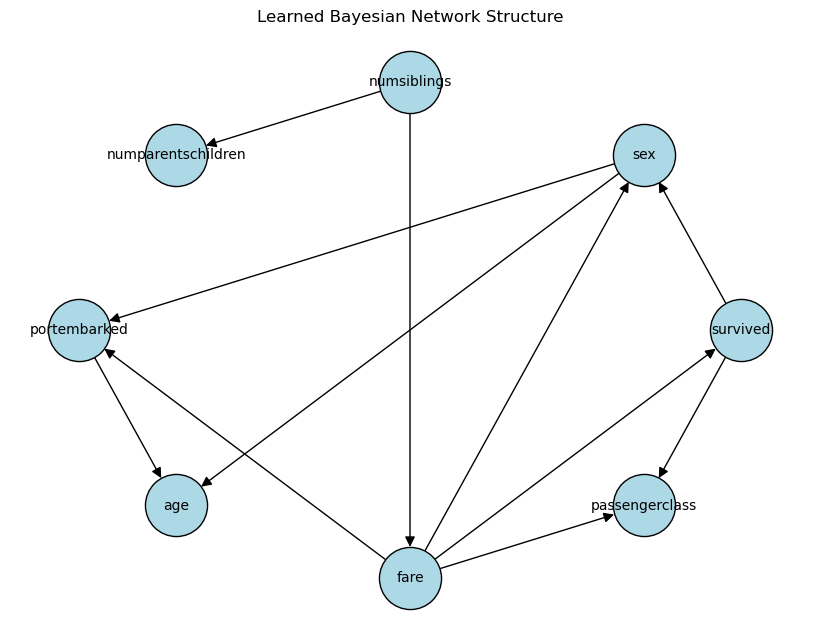

In [ ]:
import pandas as pd
from pgmpy.estimators import HillClimbSearch, BayesianEstimator, BIC
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.inference import VariableElimination
from sklearn.model_selection import train_test_split
import networkx as nx
import matplotlib.pyplot as plt
import logging

# Silence pgmpy progress bar noise
logging.getLogger("pgmpy").setLevel(logging.ERROR)

# --- Load dataset ---
data = pd.read_csv("titanic.csv")

# Select columns
cols = ["age", "portembarked", "fare", "numparentschildren", "passengerclass", "sex", "numsiblings", "survived"]
data = data[cols].dropna()

# --- Discretize continuous variables ---
for c in data.columns:
    data[c] = pd.qcut(data[c].rank(method="first"), q=3, labels=["low", "medium", "high"])

# --- Split data into train/test sets ---
train, test = train_test_split(data, test_size=0.2, random_state=42)

# --- Learn structure using Hill Climb + BIC score ---
hc = HillClimbSearch(train)
score = BIC(train)
best_model = hc.estimate(scoring_method=score)

print("Learned structure edges:")
print(best_model.edges())

# --- Fit parameters on training data ---
model = DiscreteBayesianNetwork(best_model.edges())
model.fit(train, estimator=BayesianEstimator, prior_type="BDeu")

# --- Inference ---
infer = VariableElimination(model)

# --- Predictive accuracy on test set ---
correct = 0
total = len(test)

for _, row in test.iterrows():
    evidence = row.drop("survived").to_dict()
    try:
        q = infer.map_query(variables=["survived"], evidence=evidence, show_progress=False)
        if q["survived"] == row["survived"]:
            correct += 1
    except Exception as e:
        pass

accuracy = correct / total
print(f"\nPrediction Accuracy on 'survived': {accuracy:.3f}")

# --- Visualize network ---
G = nx.DiGraph()
G.add_edges_from(model.edges())

plt.figure(figsize=(8, 6))
pos = nx.shell_layout(G)
nx.draw(G, pos, with_labels=True, node_size=2000, node_color="lightblue",
        font_size=10, arrows=True, arrowsize=15, edgecolors="black")
plt.title("Learned Bayesian Network Structure")
plt.show()
